### Imports

In [1]:
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Dataset

In [2]:
train_df = pd.read_csv("sent_train.csv")
valid_df = pd.read_csv("sent_valid.csv")

In [ ]:
# Renaming columns

train_df = train_df.rename(columns={"text": "sentence", "label": "label"})
valid_df = valid_df.rename(columns={"text": "sentence", "label": "label"})

### Convert to HuggingFace Dataset

In [4]:
train_dataset = Dataset.from_pandas(train_df)
valid_dataset = Dataset.from_pandas(valid_df)

### Load Tokenizer

In [5]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

### Tokenization Function

In [6]:
def tokenize(example):
    return tokenizer(
        example["sentence"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

In [7]:
train_dataset = train_dataset.map(tokenize, batched=True)
valid_dataset = valid_dataset.map(tokenize, batched=True)

Map: 100%|██████████| 2388/2388 [00:00<00:00, 33800.03 examples/s]


### Set Format for PyTorch

In [8]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

valid_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

### Load BERT Model

In [9]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6129.10it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

### Evaluation Metrics

In [10]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = torch.argmax(torch.tensor(logits), dim=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="macro"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "macro_f1": f1,
        "precision": precision,
        "recall": recall
    }

### Training Arguments

In [13]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True
)

### Trainer

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

### Train Model

In [15]:
trainer.train()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,0.593437,0.378905,0.853015,0.812302,0.797285,0.830410
2,0.333210,0.340617,0.881491,0.844266,0.847444,0.841721
3,0.223577,0.387017,0.881910,0.846727,0.845241,0.848606


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.41it/s]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.94it/s]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNor

TrainOutput(global_step=1791, training_loss=0.348865739065199, metrics={'train_runtime': 1013.0937, 'train_samples_per_second': 28.259, 'train_steps_per_second': 1.768, 'total_flos': 941584254516864.0, 'train_loss': 0.348865739065199, 'epoch': 3.0})

### Evaluate

In [17]:
results = trainer.predict(valid_dataset)
print(results.metrics)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'test_loss': 0.340728759765625, 'test_accuracy': 0.8814907872696818, 'test_macro_f1': 0.844265965616291, 'test_precision': 0.8474444808090681, 'test_recall': 0.8417209849552756, 'test_runtime': 16.6332, 'test_samples_per_second': 143.568, 'test_steps_per_second': 9.018}


### Save Model

In [18]:
trainer.save_model("bert_model")
tokenizer.save_pretrained("bert_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.36it/s]


('bert_model/tokenizer_config.json', 'bert_model/tokenizer.json')

Map: 100%|██████████| 2388/2388 [00:00<00:00, 36770.66 examples/s]


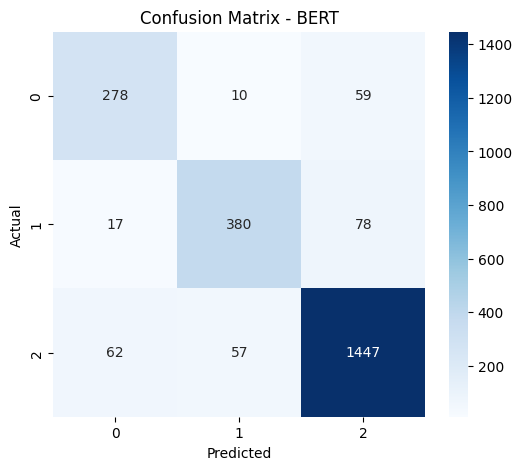

In [11]:
# Load model + tokenizer
from transformers import BertForSequenceClassification, BertTokenizer
import pandas as pd
from datasets import Dataset
import torch

model = BertForSequenceClassification.from_pretrained("bert_model")
tokenizer = BertTokenizer.from_pretrained("bert_model")

# Load validation data
valid_df = pd.read_csv("sent_valid.csv")
valid_df = valid_df.rename(columns={"text": "sentence", "label": "label"})

# Convert to dataset
valid_dataset = Dataset.from_pandas(valid_df)

# Tokenize
def tokenize(example):
    return tokenizer(
        example["sentence"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

valid_dataset = valid_dataset.map(tokenize, batched=True)

valid_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

# Create simple dataloader
from torch.utils.data import DataLoader

loader = DataLoader(valid_dataset, batch_size=16)

# Predict manually (NO Trainer needed)
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for batch in loader:
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(batch["label"].numpy())

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BERT")

plt.savefig("confusion_matrix.png")
plt.show()